In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")

In [3]:
using JLD2
using DataFrames, DataFramesMeta

In [4]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Get data from all files

In [5]:
for f in files
    close(f)
end
GC.gc()

LoadError: UndefVarError: `files` not defined

In [6]:
ks = [0.0, 0.001, 0.01, 0.1, 0.2]
files = map(ks) do k
    jldopen(@sprintf "./wrtk_2/d1_k%.1f.jld2" k)
end;
Ks = files[1]["metadata"].Ks;

In [8]:
full_df = DataFrame(;
    K=Float64[],
    k=Float64[],
    retcode=Any[],
    fT=Any[],
    fs=Any[],
)
for (k, f) in zip(ks, files)
    fKs = f["Ks"]
    results = f["results"]
    for i in 1:length(fKs)
        r = results[i]
        for (rc, fT, fs) in zip(r.retcodes, r.fTs, r.fss)
            push!(full_df, (fKs[i], k, rc, fT, fs))
        end
    end
end
df = @subset(full_df, :fT .== 1e8, :retcode .== ReturnCode.Success);
nrow(df)

1939

# Number of survivors

In [10]:
df.num_surv = num_survivors_in_space.(df.fs, 2);

In [14]:
kgroups = @groupby(df, :k);

## Box plots

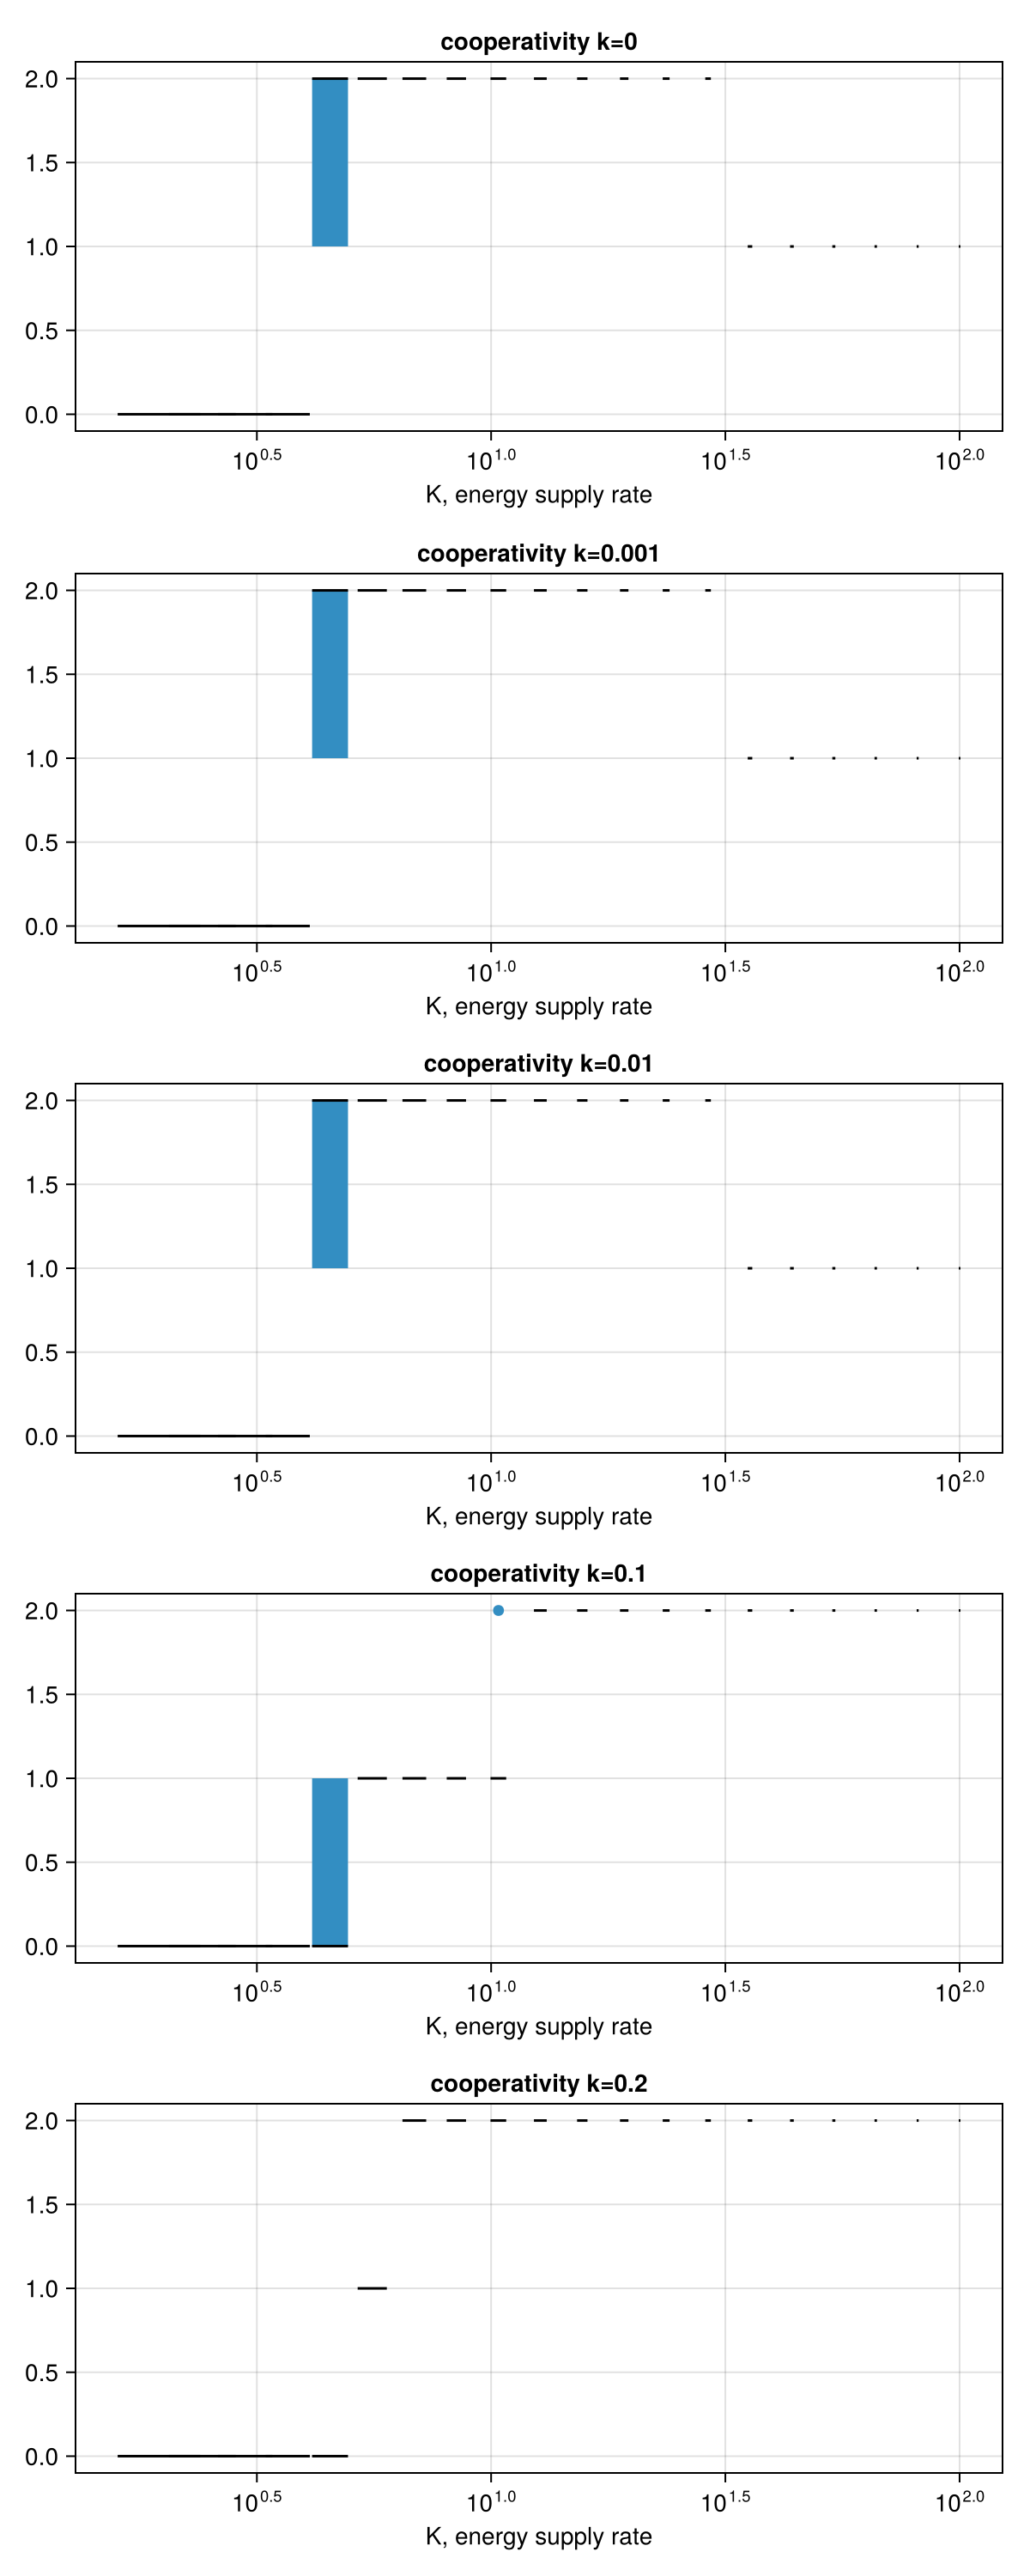

In [58]:
fig = Figure(;
    size=(600, 300 * length(kgroups))
)
for (i, sdf) in enumerate(kgroups)
    ax = Axis(fig[i,1];
        xscale=log10,
        title=(@sprintf "cooperativity k=%.3g" sdf.k[1]),
        xlabel="K, energy supply rate",
    )
    boxplot!(ax, sdf.K, sdf.num_surv)
end
Makie.save("wrtk_2/num_surv_bp.pdf", fig)
fig